In [2]:
import pandas as pd
import json
import glob
import os

def load_all_results(directory_path="../results/*.json"):
    all_dfs = []
    files = glob.glob(directory_path)
    
    for file_path in files:
        filename = os.path.basename(file_path).lower()
        with open(file_path, 'r') as f:
            data = json.load(f)
        
        info = data.get('experiment_info', {})
        model_name = info.get('model_type', 'unknown')
        
        # --- ROBUST CLASS IDENTIFICATION ---
        total_classes = info.get('n_classes', 0)
        
        # Fallback 1: Filename check
        if total_classes == 0:
            if '8way' in filename or '8-way' in filename or 'multi8' in filename:
                total_classes = 8
            elif '4way' in filename or '4-way' in filename or 'multi4' in filename:
                total_classes = 4
            else:
                total_classes = 2 # Binary default
        
        # Fallback 2: Metadata check (often different for NN)
        if total_classes == 0:
            dataset_list = str(info.get('datasets', ''))
            if '8' in dataset_list: total_classes = 8
            elif '4' in dataset_list: total_classes = 4
            else: total_classes = 2

        temp_df = pd.DataFrame(data['results'])
        temp_df['model_family'] = model_name
        temp_df['total_classes'] = total_classes
        
        # CATEGORIZATION
        q_keys = ['quantum', 'vqc', 'qsvc', 'kernel']
        if any(k in model_name.lower() or k in filename for k in q_keys):
            temp_df['category'] = 'Quantum'
        else:
            temp_df['category'] = 'Classical'
            
        all_dfs.append(temp_df)
    
    master_df = pd.concat(all_dfs, ignore_index=True)
    master_df['accuracy'] = pd.to_numeric(master_df['accuracy'], errors='coerce')
    master_df['training_time_seconds'] = pd.to_numeric(master_df['training_time_seconds'], errors='coerce')
    return master_df

df = load_all_results()
print(df.groupby(['total_classes', 'category']).size())


total_classes  category 
2              Classical    240
               Quantum       70
4              Classical    120
               Quantum       60
8              Classical    120
               Quantum       60
dtype: int64


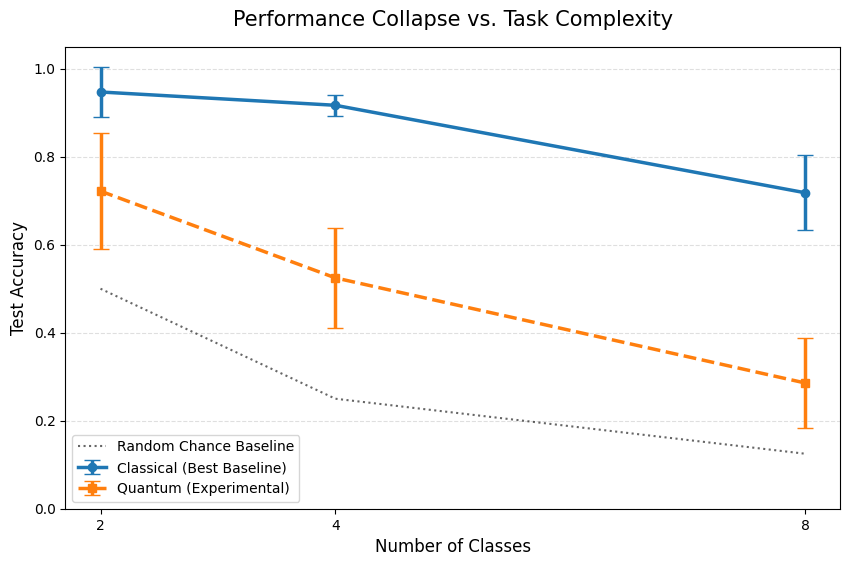

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Define colors for consistency
colors = {'Classical': '#1f77b4', 'Quantum': '#ff7f0e'}

# Grouping by class count and Category
summary = df.groupby(['total_classes', 'category'])['accuracy'].agg(['mean', 'std']).unstack()

# Plot Classical (Solid line, Blue)
plt.errorbar(summary.index, summary['mean']['Classical'], 
             yerr=summary['std']['Classical'], fmt='o-', capsize=6, 
             label='Classical (Best Baseline)', color=colors['Classical'], linewidth=2.5)

# Plot Quantum (Dashed line, Orange)
plt.errorbar(summary.index, summary['mean']['Quantum'], 
             yerr=summary['std']['Quantum'], fmt='s--', capsize=6, 
             label='Quantum (Experimental)', color=colors['Quantum'], linewidth=2.5)

# Add the 1/N Random Chance Baseline
x_ticks = [2, 4, 8]
plt.plot(x_ticks, [1/x for x in x_ticks], 'k:', alpha=0.6, label='Random Chance Baseline')

plt.title("Performance Collapse vs. Task Complexity", fontsize=15, pad=15)
plt.xlabel("Number of Classes", fontsize=12)
plt.ylabel("Test Accuracy", fontsize=12)
plt.xticks(x_ticks)
plt.ylim(0, 1.05)
plt.legend(frameon=True, loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.savefig('accuracy_complexity_collapse.png', bbox_inches='tight')
plt.show()


<Figure size 1200x600 with 0 Axes>

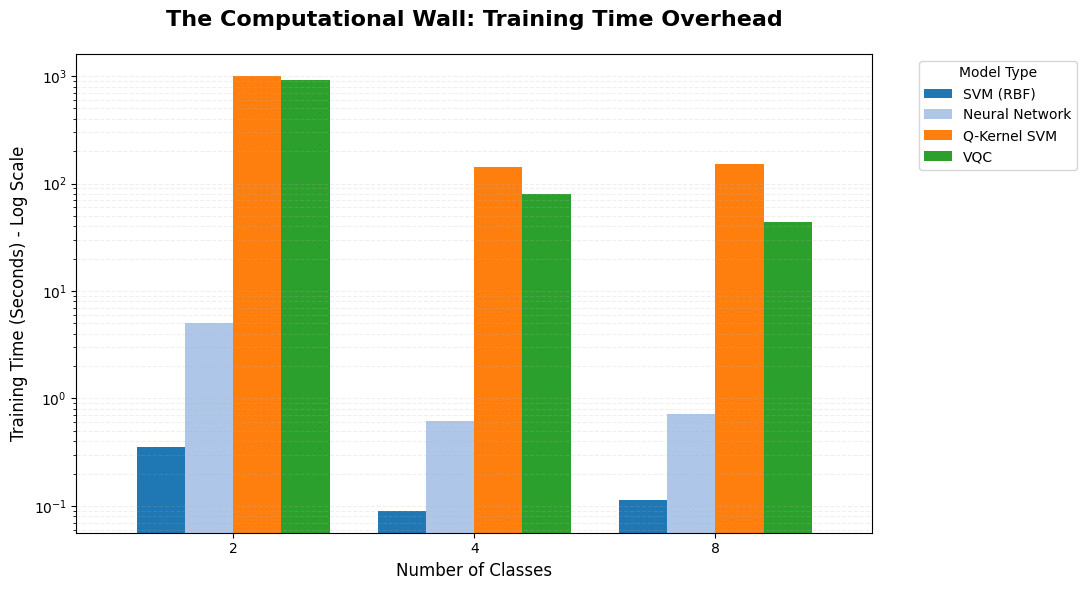

In [21]:
# 1. Re-apply the mapping to the new df
model_map = {
    'classical_svm_rbf': 'SVM (RBF)',
    'classical_knn': 'k-NN',
    'classical_logistic_regression': 'LogReg',
    'shallow_neural_network': 'Neural Network',
    'quantum_kernel_svm': 'Q-Kernel SVM',
    'quantum_kernel_svm_4way': 'Q-Kernel SVM',
    'quantum_kernel_svm_8way': 'Q-Kernel SVM',
    'variational_quantum_classifier': 'VQC',
    'variational_quantum_classifier_4way': 'VQC',
    'variational_quantum_classifier_8way': 'VQC'
}
df['model_label'] = df['model_family'].map(model_map)

# 2. Plot Training Time (using max time per class count for clear 'Worst Case' comparison)
plt.figure(figsize=(12, 6))

# Grouping by classes and model label
time_summary = df.groupby(['total_classes', 'model_label'])['training_time_seconds'].mean().unstack()

# Filter for the 4 most important models to keep the bar chart clean
models_to_show = ['SVM (RBF)', 'Neural Network', 'Q-Kernel SVM', 'VQC']
time_plot_df = time_summary[models_to_show]

# Plotting with Log Scale
ax = time_plot_df.plot(kind='bar', figsize=(11, 6), width=0.8, color=['#1f77b4', '#aec7e8', '#ff7f0e', '#2ca02c'])

plt.yscale('log')
plt.title("The Computational Wall: Training Time Overhead", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Training Time (Seconds) - Log Scale", fontsize=12)
plt.xlabel("Number of Classes", fontsize=12)
plt.xticks(rotation=0)
plt.grid(which='both', axis='y', linestyle='--', alpha=0.2)
plt.legend(title="Model Type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('computational_wall_final.png', bbox_inches='tight')
plt.show()


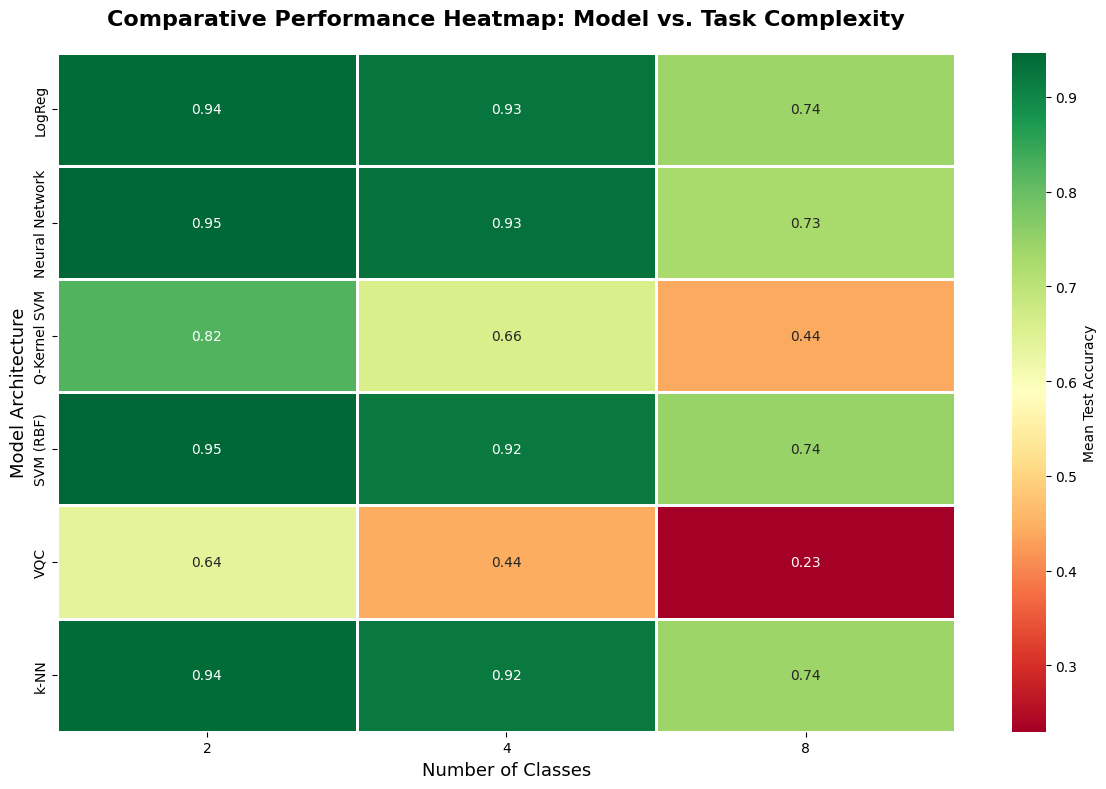

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the specific training sizes we want to compare
target_samples = [400, 500]

# 2. Filter and Pivot
# We filter for the largest shared 'n' values to ensure a fair comparison
filtered_df = df[df['n_train'].isin(target_samples)]

# Create the pivot table: Rows = Models, Columns = Number of Classes
pivot_df = filtered_df.groupby(['model_label', 'total_classes'])['accuracy'].mean().unstack()

# 3. Plotting
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, 
            annot=True, 
            cmap='RdYlGn', 
            fmt='.2f', 
            linewidths=1,
            cbar_kws={'label': 'Mean Test Accuracy'})

plt.title("Comparative Performance Heatmap: Model vs. Task Complexity", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Number of Classes", fontsize=13)
plt.ylabel("Model Architecture", fontsize=13)

plt.tight_layout()
plt.savefig('performance_heatmap_final.png')
plt.show()


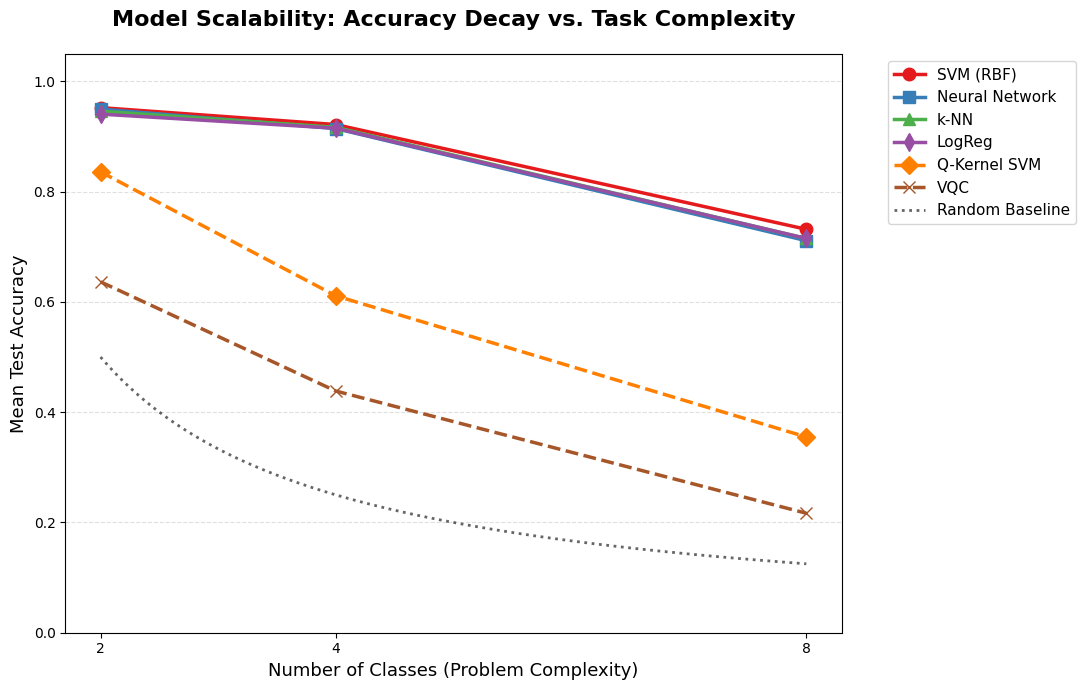

In [23]:
import numpy as np

plt.figure(figsize=(11, 7))

# 1. Group by classes and model to get the mean accuracy
scalability_df = df.groupby(['total_classes', 'model_label'])['accuracy'].mean().unstack()

# 2. Define models with high-contrast colors and styles
# Classical: Solid lines, distinct colors
# Quantum: Dashed lines, warm 'warning' colors
models = ['SVM (RBF)', 'Neural Network', 'k-NN', 'LogReg', 'Q-Kernel SVM', 'VQC']
styles = ['o-', 's-', '^-', 'd-', 'D--', 'x--'] 
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628'] # Qualitative Set1

for i, model in enumerate(models):
    if model in scalability_df.columns:
        plt.plot(scalability_df.index, scalability_df[model], styles[i], 
                 label=model, color=colors[i], linewidth=2.5, markersize=9)

# 3. Add Random Chance Baseline (Theoretical Floor)
x_range = np.linspace(2, 8, 100)
plt.plot(x_range, 1/x_range, 'k:', alpha=0.6, label='Random Baseline', linewidth=2)

# 4. Professional Formatting
plt.title("Model Scalability: Accuracy Decay vs. Task Complexity", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Number of Classes (Problem Complexity)", fontsize=13)
plt.ylabel("Mean Test Accuracy", fontsize=13)
plt.xticks([2, 4, 8]) 
plt.ylim(0, 1.05)

# 5. Legend and Grid
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, fontsize=11)
plt.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('accuracy_scalability_v3.png', bbox_inches='tight')
plt.show()


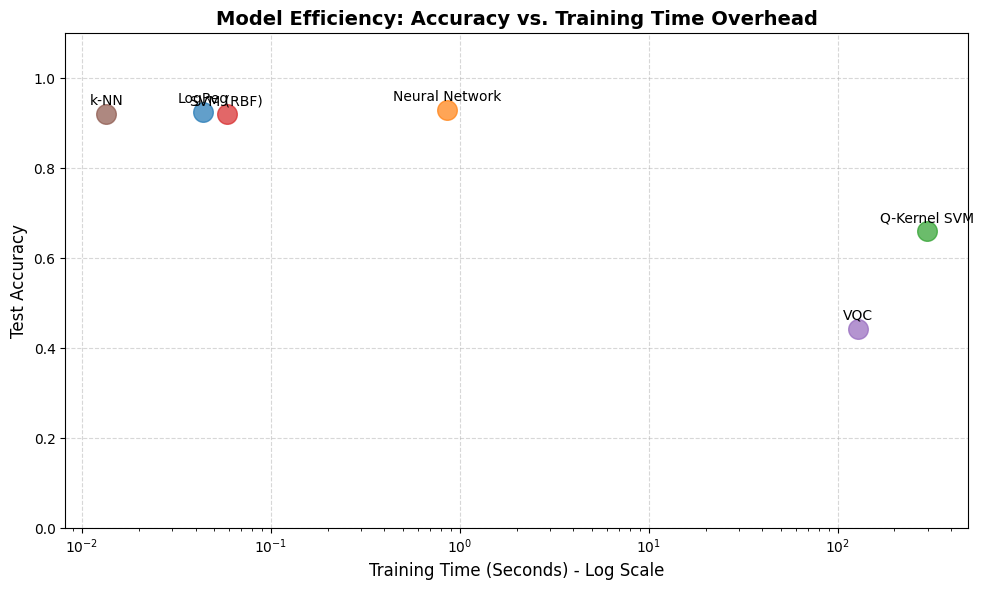

In [24]:
plt.figure(figsize=(10, 6))

# Use a specific task (e.g., 4-way, n=400) for a clean snapshot
df_snap = df[(df['total_classes'] == 4) & (df['n_train'] == 400)]
summary = df_snap.groupby('model_label').agg({'accuracy': 'mean', 'training_time_seconds': 'mean'})

for model in summary.index:
    plt.scatter(summary.loc[model, 'training_time_seconds'], 
                summary.loc[model, 'accuracy'], 
                s=200, label=model, alpha=0.7)
    plt.text(summary.loc[model, 'training_time_seconds'], 
             summary.loc[model, 'accuracy'] + 0.02, model, fontsize=10, ha='center')

plt.xscale('log')
plt.title("Model Efficiency: Accuracy vs. Training Time Overhead", fontsize=14, fontweight='bold')
plt.xlabel("Training Time (Seconds) - Log Scale", fontsize=12)
plt.ylabel("Test Accuracy", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, 1.1)

plt.tight_layout()
plt.savefig('efficiency_scatter.png')
plt.show()


/var/folders/l1/_n8mydv120j5gzcb_l0y2slm0000gn/T/ipykernel_1856/3703738257.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=model_names, patch_artist=True,


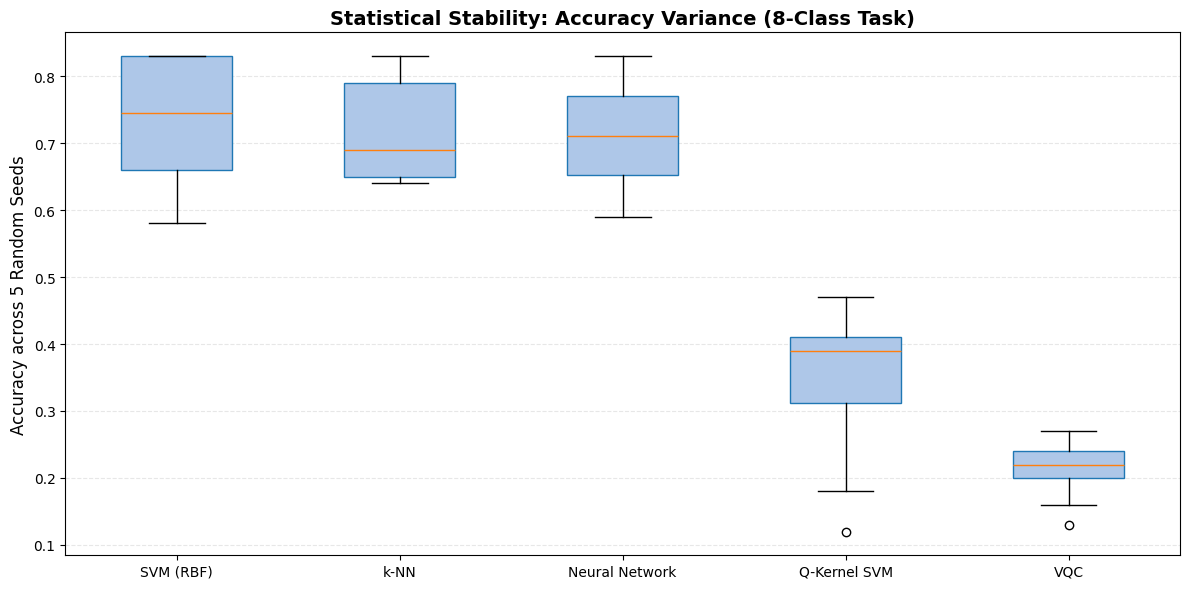

In [25]:
plt.figure(figsize=(12, 6))

# Filter for the hardest task to show maximum variance
df_hard = df[df['total_classes'] == 8]

# Create a list of data arrays for each model
model_names = ['SVM (RBF)', 'k-NN', 'Neural Network', 'Q-Kernel SVM', 'VQC']
data_to_plot = [df_hard[df_hard['model_label'] == m]['accuracy'] for m in model_names]

plt.boxplot(data_to_plot, labels=model_names, patch_artist=True, 
            boxprops=dict(facecolor='#aec7e8', color='#1f77b4'))

plt.title("Statistical Stability: Accuracy Variance (8-Class Task)", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy across 5 Random Seeds", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('stability_boxplot.png')
plt.show()


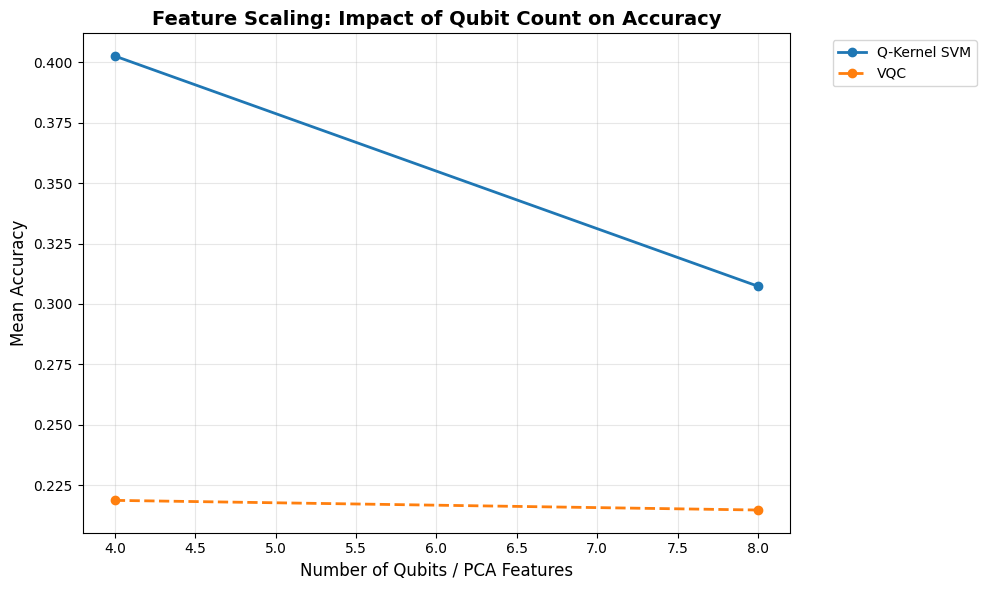

In [26]:
plt.figure(figsize=(10, 6))

# Group by model and qubit count for the 8-class task
res_scaling = df[df['total_classes'] == 8].groupby(['model_label', 'n_qubits'])['accuracy'].mean().unstack()

for model in res_scaling.index:
    style = '-' if 'Quantum' not in model and 'VQC' not in model else '--'
    plt.plot(res_scaling.columns, res_scaling.loc[model], 'o' + style, label=model, linewidth=2)

plt.title("Feature Scaling: Impact of Qubit Count on Accuracy", fontsize=14, fontweight='bold')
plt.xlabel("Number of Qubits / PCA Features", fontsize=12)
plt.ylabel("Mean Accuracy", fontsize=12)
plt.xticks()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('qubit_scaling_slopes.png')
plt.show()
